In [1]:
# plot metrics in different experiments
import numpy as np
import pandas as pd
import pylab as plt
import seaborn as sn
import sys
sys.path.append('../')
import MHMDS.embed_funs as emb
from glob import glob

In [2]:
# plot parameters
plt.style.use('my_journal.mplstyle')
def clean_axis(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3)

In [3]:
# experiment 1: only one layer, effect of cluster number/size 
fdname = '../MultiscalehMDS_feature/result/FeatMat_Paul_PCA100/exp1-rep/'
alllist = []
for file in glob(fdname+'*.csv'):
    temp = pd.read_csv(file,index_col=0)
    temp = temp.iloc[np.sort(np.array([i*4 for i in range(20)]+[i*4+1 for i in range(20)]+[i*4+3 for i in range(20)])),1:]
    temp['ncls'] = int(file.split('_')[-9])
    temp['logncls'] = np.log10(int(file.split('_')[-9]))
    alllist.append(temp.reset_index())

In [4]:
exp1 = pd.concat(alllist,axis=0).reset_index().iloc[:,2:]

In [5]:
exp1

,Step,Qlocal,Qglobal,corr,runningtime,curvature,nunit,maxsizeofunit,rep,ncls,logncls
0,1,0.453916,0.861624,0.896108,753.185274,8.40410,500.0,1.0,0,500,2.698970
1,2,0.419234,0.822943,0.838318,45.998819,8.40410,500.0,83.0,0,500,2.698970
2,Avedmat,NaN,NaN,NaN,0.056287,NaN,NaN,NaN,0,500,2.698970
3,1,0.463626,0.864893,0.908914,1405.501122,8.43926,500.0,1.0,1,500,2.698970
4,2,0.421244,0.821995,0.843786,49.920781,8.43926,500.0,83.0,1,500,2.698970
...,...,...,...,...,...,...,...,...,...,...,...
1075,2,0.404753,0.830263,0.860488,105.377671,7.08261,75.0,177.0,18,75,1.875061
1076,Avedmat,NaN,NaN,NaN,0.006673,NaN,NaN,NaN,18,75,1.875061
1077,1,0.540737,0.897730,0.982402,7.149975,6.80319,75.0,1.0,19,75,1.875061
1078,2,0.414661,0.833285,0.861604,98.816591,6.80319,75.0,177.0,19,75,1.875061


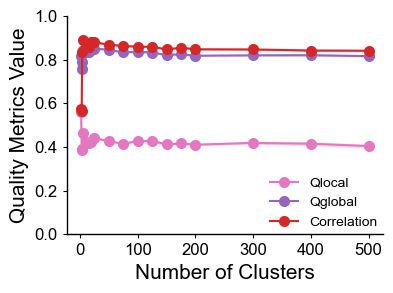

In [14]:
# plot metrics versus dimension, all in one
# Q local, Q global, corr versus metrics

fig, axs = plt.subplots(1,1,figsize=(4,3))
sn.lineplot(data=exp1[exp1.Step=='2'],x='ncls',y='Qlocal',marker='o',ax=axs,color='tab:pink',label='Qlocal',
           markeredgewidth=0,markersize=8)
axs.set_ylim([0.0,1.0])
axs.set_xlabel('Number of Clusters',fontsize=15)
axs.set_ylabel('Quality Metrics Value',fontsize=15)
sn.lineplot(data=exp1[exp1.Step=='2'],x='ncls',y='Qglobal',marker='o',ax=axs,color='tab:purple',label='Qglobal',
           markeredgewidth=0,markersize=8)

sn.lineplot(data=exp1[exp1.Step=='2'],x='ncls',y='corr',marker='o',ax=axs,color='tab:red',label='Correlation',
           markeredgewidth=0,markersize=8)

axs.legend(loc='lower right', borderaxespad=0,fontsize=10,
             title_fontsize=15)

axs.tick_params(axis="x", labelsize=12)  
axs.tick_params(axis="y", labelsize=12)

plt.tight_layout()
clean_axis(ax=axs)

# plt.savefig('ncls_metrics.svg',format='svg',transparent=True)

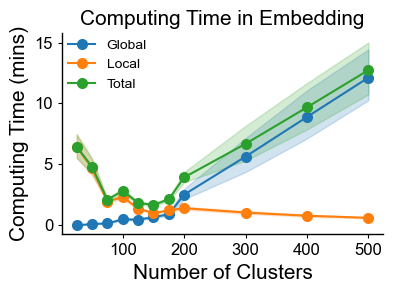

In [ ]:
# plot each computing time metrics versus threshold and Nn: all in one, not showing nns
fig, axs = plt.subplots(1,1,figsize=(4,3))
exp1['mins'] = exp1['runningtime']/60.0

sn.lineplot(data=exp1[(exp1.Step=='1') & (exp1.ncls >= 25)],x='ncls',y='mins',marker="o",ax=axs,label='Global',
           markeredgewidth=0,markersize=8)

sn.lineplot(data=exp1[(exp1.Step=='2') & (exp1.ncls >= 25)],x='ncls',y='mins',marker="o",ax=axs,label='Local',
           markeredgewidth=0,markersize=8)

sn.lineplot(data=exp1[(exp1.ncls >= 25)].groupby(['ncls','rep']).sum(),x='ncls',y='mins',marker='o',ax=axs,label='Total',
           markeredgewidth=0,markersize=8)

axs.set_title('Computing Time in Embedding',fontsize=15)
axs.set_xlabel('Number of Clusters',fontsize=15)
axs.set_ylabel('Computing Time (mins)',fontsize=15)


axs.legend(loc='upper left', borderaxespad=0,fontsize=10,
             title_fontsize=15)


axs.tick_params(axis="x", labelsize=12)  
axs.tick_params(axis="y", labelsize=12)

plt.tight_layout()
clean_axis(ax=axs)

# plt.savefig('ncls_runningtime.svg',format='svg',transparent=True)


In [16]:
# exp2: effect of dimensions, only one layer,2-3-4-5-6-7-8-9-10-15-20

fdname = '../MultiscalehMDS_feature/result/FeatMat_Paul_PCA100/exp2-rep/'
alllist = []
for dim in [2,3,4,5,6,7,8,9,10,15,20]:
    temp = pd.read_csv(fdname+'allmetric_rep20_cls_100_Nn_20_Nd_%i_min_1_max_3000.csv'%(dim),index_col=0)
    temp = temp.iloc[np.sort(np.array([i*4 for i in range(20)]+[i*4+1 for i in range(20)]+[i*4+3 for i in range(20)])),1:]
    temp['dim'] = dim
    alllist.append(temp.reset_index())

In [17]:
exp2 = pd.concat(alllist,axis=0).reset_index().iloc[:,2:]

In [18]:
exp2

,Step,Qlocal,Qglobal,corr,runningtime,curvature,nunit,maxsizeofunit,rep,dim
0,1,0.525946,0.898597,0.936070,15.298093,7.10532,100.0,1.0,0,2
1,2,0.399751,0.829633,0.760291,49.308016,7.10532,100.0,201.0,0,2
2,Avedmat,NaN,NaN,NaN,0.014704,NaN,NaN,NaN,0,2
3,1,0.516409,0.884572,0.918545,9.793761,5.82030,100.0,1.0,1,2
4,2,0.411912,0.845087,0.791439,21.315903,5.82030,100.0,201.0,1,2
...,...,...,...,...,...,...,...,...,...,...
655,2,0.635799,0.913933,0.986117,157.335268,3.98835,100.0,201.0,18,20
656,Avedmat,NaN,NaN,NaN,0.006988,NaN,NaN,NaN,18,20
657,1,0.840000,0.958011,0.999355,21.897036,3.94503,100.0,1.0,19,20
658,2,0.632045,0.913234,0.986071,177.153060,3.94503,100.0,201.0,19,20


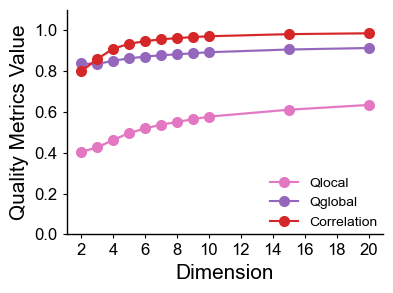

In [ ]:
# plot metrics versus dimension, all in one
# Q local, Q global, corr versus metrics
fig, axs = plt.subplots(1,1,figsize=(4,3))
sn.lineplot(data=exp2[exp2.Step=='2'],x='dim',y='Qlocal',marker='o',ax=axs,color='tab:pink',label='Qlocal',
           markeredgewidth=0,markersize=8)

axs.set_xlabel('Dimension',fontsize=15)
axs.set_ylabel('Quality Metrics Value',fontsize=15)
sn.lineplot(data=exp2[exp2.Step=='2'],x='dim',y='Qglobal',marker='o',ax=axs,color='tab:purple',label='Qglobal',
           markeredgewidth=0,markersize=8)

sn.lineplot(data=exp2[exp2.Step=='2'],x='dim',y='corr',marker='o',ax=axs,color='tab:red',label='Correlation',
           markeredgewidth=0,markersize=8)

axs.legend(loc='lower right', borderaxespad=0,fontsize=10,
             title_fontsize=15)



ticks = [2,4,6,8,10,12,14,16,18,20]

axs.set_xticks(ticks,[str(s) for s in ticks])

axs.tick_params(axis="x", labelsize=12)  
axs.tick_params(axis="y", labelsize=12)
axs.set_ylim([0.0,1.1])

plt.tight_layout()
clean_axis(ax=axs)

# plt.savefig('Dimension_metrics.svg',format='svg',transparent=True)

In [20]:
# experiment 4: effect redivide large clusters
# Different max threshold 
fdname = '../MultiscalehMDS_feature/result/FeatMat_Paul_PCA100/exp4-rep/'
alllist = []
for maxcls in [50,100,200,300,400,3000]:
    temp = pd.read_csv(fdname+'allmetric_rep50_cls_25_Nn_20_Nd_3_min_1_max_%i.csv'%(maxcls),index_col=0)
    temp = temp.iloc[np.sort(np.array([i*4 for i in range(50)]+[i*4+1 for i in range(50)]+[i*4+3 for i in range(50)])),1:]
    temp['maxcls'] = maxcls
    alllist.append(temp.reset_index())

In [21]:
exp4 = pd.concat(alllist,axis=0).reset_index().iloc[:,2:]

In [22]:
exp4

,Step,Qlocal,Qglobal,corr,runningtime,curvature,nunit,maxsizeofunit,rep,maxcls
0,1,0.577562,0.894182,0.954215,299.541229,7.96990,207.0,1.0,0,50
1,2,0.371988,0.801660,0.837150,93.047368,7.96990,207.0,50.0,0,50
2,Avedmat,NaN,NaN,NaN,0.028246,NaN,NaN,NaN,0,50
3,1,0.534207,0.876788,0.950609,168.865776,7.17856,207.0,1.0,1,50
4,2,0.373386,0.800143,0.829514,76.126784,7.17856,207.0,50.0,1,50
...,...,...,...,...,...,...,...,...,...,...
895,2,0.438527,0.849784,0.879531,420.117060,5.23093,25.0,501.0,48,3000
896,Avedmat,NaN,NaN,NaN,0.018654,NaN,NaN,NaN,48,3000
897,1,0.630000,0.877641,0.993482,0.652993,5.18942,25.0,1.0,49,3000
898,2,0.427463,0.847477,0.872822,280.512744,5.18942,25.0,501.0,49,3000


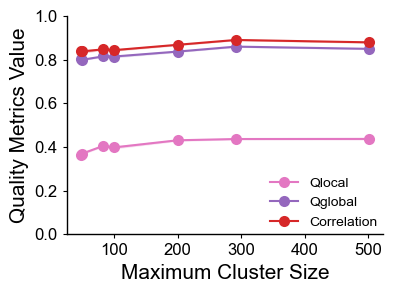

In [23]:
# plot metrics versus dimension, all in one

fig, axs = plt.subplots(1,1,figsize=(4,3))
sn.lineplot(data=exp4[exp4.Step=='2'],x='maxsizeofunit',y='Qlocal',marker='o',ax=axs,color='tab:pink',label='Qlocal',
           markeredgewidth=0,markersize=8)

axs.set_xlabel('Maximum Cluster Size',fontsize=15)
axs.set_ylabel('Quality Metrics Value',fontsize=15)
sn.lineplot(data=exp4[exp4.Step=='2'],x='maxsizeofunit',y='Qglobal',marker='o',ax=axs,color='tab:purple',label='Qglobal',
           markeredgewidth=0,markersize=8)

sn.lineplot(data=exp4[exp4.Step=='2'],x='maxsizeofunit',y='corr',marker='o',ax=axs,color='tab:red',label='Correlation',
           markeredgewidth=0,markersize=8)

axs.legend(loc='lower right', borderaxespad=0,fontsize=10,
             title_fontsize=15)

axs.set_ylim([0.0,1.0])
axs.tick_params(axis="x", labelsize=12)  
axs.tick_params(axis="y", labelsize=12)

plt.tight_layout()
clean_axis(ax=axs)

# plt.savefig('Maxpop_metrics.svg',format='svg',transparent=True)


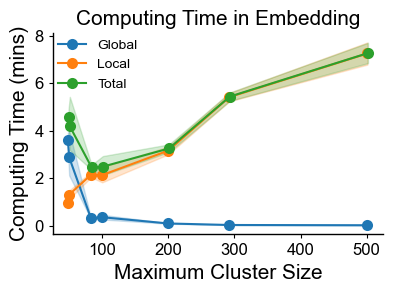

In [24]:
# plot each computing time metrics versus max pop size

fig, axs = plt.subplots(1,1,figsize=(4,3))
exp4['mins'] = exp4['runningtime']/60.0
df_ = pd.DataFrame({'x':np.array(exp4[exp4.Step=='2']['maxsizeofunit']),
                    'y':np.array(exp4[exp4.Step=='1']['mins'])})

sn.lineplot(df_,x='x',y='y',marker="o",ax=axs,label='Global',
           markeredgewidth=0,markersize=8)

sn.lineplot(data=exp4[exp4.Step=='2'],x='maxsizeofunit',y='mins',marker="o",ax=axs,label='Local',
           markeredgewidth=0,markersize=8)

sn.lineplot(data=exp4.groupby(['maxcls','rep']).sum(),x='maxsizeofunit',y='mins',marker='o',ax=axs,label='Total',
           markeredgewidth=0,markersize=8)

axs.set_title('Computing Time in Embedding',fontsize=15)
axs.set_xlabel('Maximum Cluster Size',fontsize=15)
axs.set_ylabel('Computing Time (mins)',fontsize=15)

axs.legend(loc='upper left', borderaxespad=0,fontsize=10,
             title_fontsize=15)


axs.tick_params(axis="x", labelsize=12)  
axs.tick_params(axis="y", labelsize=12)

plt.tight_layout()
clean_axis(ax=axs)

# plt.savefig('Maxpop_computingtime.svg',format='svg',transparent=True)


In [25]:
# exp 5: effect of nn depending on different dimensions
fdname = '../MultiscalehMDS_feature/result/FeatMat_Paul_PCA100/exp5-rep/'
alllist = []
for file in glob(fdname+'*.csv'):
    temp = pd.read_csv(file,index_col=0)
    temp = temp.iloc[np.sort(np.array([i*4 for i in range(20)]+[i*4+1 for i in range(20)]+[i*4+3 for i in range(20)])),1:]
    temp['dim'] = int(file.split('_')[-5])
    temp['Nn'] = int(file.split('_')[-7])
    alllist.append(temp.reset_index())

In [26]:
exp5 = pd.concat(alllist,axis=0).reset_index().iloc[:,2:]

In [27]:
exp5.head()

,Step,Qlocal,Qglobal,corr,runningtime,curvature,nunit,maxsizeofunit,rep,dim,Nn
0,1,0.713333,0.916564,0.997735,4.941040,5.53223,50.0,1.0,0,5,25
1,2,0.502113,0.871349,0.936755,196.174747,5.53223,50.0,266.0,0,5,25
2,Avedmat,NaN,NaN,NaN,0.004739,NaN,NaN,NaN,0,5,25
3,1,0.733333,0.917990,0.997761,5.059078,5.59732,50.0,1.0,1,5,25
4,2,0.506426,0.872621,0.937502,226.163067,5.59732,50.0,266.0,1,5,25


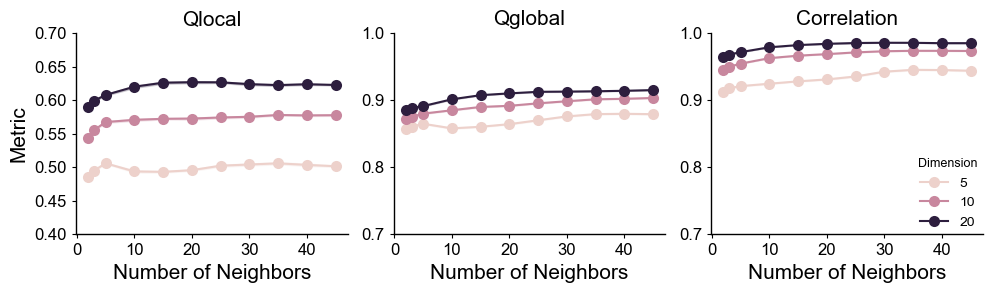

In [30]:
# embedding metric depending on Nn and dimension
# Q local, Q global, corr versus metrics
fig, axs = plt.subplots(1,3,figsize=(10,3))
sn.lineplot(data=exp5[exp5.Step=='2'],x='Nn',y='Qlocal',hue='dim',marker='o',ax=axs[0],
            markeredgewidth=0,markersize=8)
axs[0].set_title('Qlocal',fontsize=15)
axs[0].set_xlabel('Number of Neighbors',fontsize=15)
axs[0].set_ylabel('Metric',fontsize=15)
axs[0].set_ylim([0.4,0.7])


sn.lineplot(data=exp5[exp5.Step=='2'],x='Nn',y='Qglobal',hue='dim',marker='o',ax=axs[1],
           markeredgewidth=0,markersize=8)
axs[1].set_title('Qglobal',fontsize=15)
axs[1].set_xlabel('Number of Neighbors',fontsize=15)
axs[1].set_ylabel('',fontsize=15)
axs[1].set_ylim([0.7,1])

sn.lineplot(data=exp5[exp5.Step=='2'],x='Nn',y='corr',hue='dim',marker='o',ax=axs[2],
           markeredgewidth=0,markersize=8)
axs[2].set_title('Correlation',fontsize=15)
axs[2].set_xlabel('Number of Neighbors',fontsize=15)
axs[2].set_ylabel('',fontsize=15)
axs[2].set_ylim([0.7,1])

axs[2].legend(loc='lower right', borderaxespad=0,fontsize=10,
             title_fontsize=9,title='Dimension')
# remove legend from the first two axes
axs[0].get_legend().remove()
axs[1].get_legend().remove()
for i in range(3):
    axs[i].tick_params(axis="x", labelsize=12)  
    axs[i].tick_params(axis="y", labelsize=12)
    
    clean_axis(ax=axs[i])

plt.tight_layout()

# plt.savefig('nn_dim_metrics.svg',format='svg',transparent=True)


In [ ]:
# exp 6: effect of deleting and remapping outliers (min cls size)
fdname = '../MultiscalehMDS_feature/result/FeatMat_Paul_PCA100/exp6-rep/'
alllist = []
for file in glob(fdname+'*.csv'):
    temp = pd.read_csv(file,index_col=0)
    temp['mincls'] = int(file.split('_')[-3])
    if int(file.split('_')[-5]) == 1:
        temp.iloc[temp.Step=='MapOutlier',2:] = temp[temp.Step=='2'].iloc[:,2:]
        temp.iloc[temp.Step=='MapOutlier',5] = 0.0

    alllist.append(temp.reset_index())

In [32]:
exp6 = pd.concat(alllist,axis=0).iloc[:,2:].reset_index().iloc[:,1:]

In [33]:
exp6

,Step,Qlocal,Qglobal,corr,runningtime,curvature,nunit,maxsizeofunit,rep,mincls
0,1,0.678628,0.925960,0.990943,3.488014,6.08474,49.0,1.0,0,5
1,2,0.484181,0.871650,0.897300,114.800882,6.08474,49.0,201.0,0,5
2,MapOutlier,0.479890,0.871849,0.920997,1.671921,6.08474,NaN,NaN,0,5
3,Avedmat,NaN,NaN,NaN,0.005326,NaN,NaN,NaN,0,5
4,1,0.634779,0.914726,0.991417,5.103531,6.20722,49.0,1.0,1,5
...,...,...,...,...,...,...,...,...,...,...
2155,Avedmat,NaN,NaN,NaN,0.005111,NaN,NaN,NaN,18,60
2156,1,0.812500,0.976474,0.996379,0.122543,3.05645,21.0,1.0,19,60
2157,2,0.531374,0.904188,0.878777,61.556495,3.05645,21.0,201.0,19,60
2158,MapOutlier,0.458455,0.857939,0.884342,35.933625,3.05645,NaN,NaN,19,60


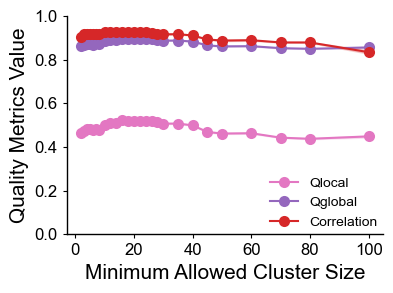

In [34]:
# Q local, Q global, corr versus metrics
fig, axs = plt.subplots(1,1,figsize=(4,3))
sn.lineplot(data=exp6[exp6.Step=='MapOutlier'],x='mincls',y='Qlocal',marker='o',ax=axs,color='tab:pink',label='Qlocal',
           markeredgewidth=0,markersize=8)

axs.set_xlabel('Minimum Allowed Cluster Size',fontsize=15)
axs.set_ylabel('Quality Metrics Value',fontsize=15)
sn.lineplot(data=exp6[exp6.Step=='MapOutlier'],x='mincls',y='Qglobal',marker='o',ax=axs,color='tab:purple',label='Qglobal',
           markeredgewidth=0,markersize=8)

sn.lineplot(data=exp6[exp6.Step=='MapOutlier'],x='mincls',y='corr',marker='o',ax=axs,color='tab:red',label='Correlation',
           markeredgewidth=0,markersize=8)

axs.legend(loc='lower right', borderaxespad=0,fontsize=10,
             title_fontsize=15)

axs.set_ylim([0.0,1.0])
axs.tick_params(axis="x", labelsize=12)  
axs.tick_params(axis="y", labelsize=12)

plt.tight_layout()
clean_axis(ax=axs)

# plt.savefig('minpop_metrics.svg',format='svg',transparent=True)



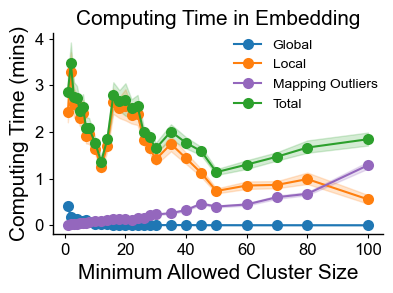

In [35]:
# plot each computing time metrics versus max pop size

fig, axs = plt.subplots(1,1,figsize=(4,3))
exp6['mins'] = exp6['runningtime']/60.0

df_ = pd.DataFrame({'x':np.array(exp6[exp6.Step=='2']['mincls']),
                    'y':np.array(exp6[exp6.Step=='1']['mins'])})

sn.lineplot(df_,x='x',y='y',marker="o",ax=axs,label='Global',
           markeredgewidth=0,markersize=8,color='tab:blue')

sn.lineplot(data=exp6[exp6.Step=='2'],x='mincls',y='mins',marker="o",ax=axs,label='Local',
           markeredgewidth=0,markersize=8,color='tab:orange')

df_ = pd.DataFrame({'x':np.array(exp6[exp6.Step=='2']['mincls']),
                    'y':np.array(exp6[exp6.Step=='MapOutlier']['mins'])})

sn.lineplot(df_,x='x',y='y',marker="o",ax=axs,label='Mapping Outliers',
           markeredgewidth=0,markersize=8,color='tab:purple')

sn.lineplot(data=exp6.groupby(['mincls','rep']).sum(),x='mincls',y='mins',marker='o',ax=axs,label='Total',
           markeredgewidth=0,markersize=8,color='tab:green')

axs.set_title('Computing Time in Embedding',fontsize=15)
axs.set_xlabel('Minimum Allowed Cluster Size',fontsize=15)
axs.set_ylabel('Computing Time (mins)',fontsize=15)

axs.legend(loc='upper right', borderaxespad=0,fontsize=10,
             title_fontsize=15)


axs.tick_params(axis="x", labelsize=12)  
axs.tick_params(axis="y", labelsize=12)

plt.tight_layout()
clean_axis(ax=axs)

# plt.savefig('minpop_computingtime.svg',format='svg',transparent=True)
